## Test functions for run analysis

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from src.paths import *
from src.utils import compare_inis
from src.models import generate_HBV_parameters

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
Kerki_station_latitude = 37.8396310038444 #Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334

station_latitude = 43.95
station_longitude = 67.05

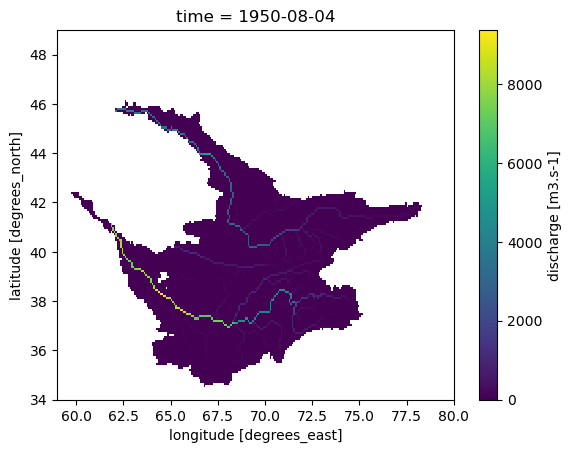

In [3]:
path_to_file_2rivers = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_101135/netcdf/discharge_dailyTot_output.nc"
ds_2riv = xr.open_dataset(path_to_file_2rivers)
ds_2riv['discharge'].isel(time=-150).plot()
da_2riv_a=ds_2riv['discharge'].isel(time=-150)

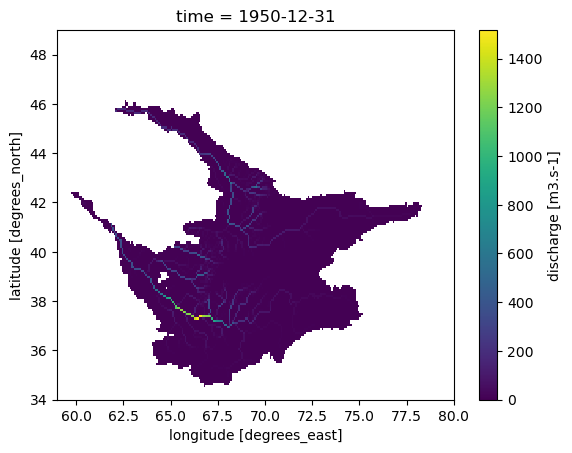

In [4]:
path_to_file_2rivers_b = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_105252/netcdf/discharge_dailyTot_output.nc"
ds_2riv_b = xr.open_dataset(path_to_file_2rivers_b)
ds_2riv_b['discharge'].isel(time=-1).plot()
da_2riv_b=ds_2riv_b['discharge'].isel(time=-150)

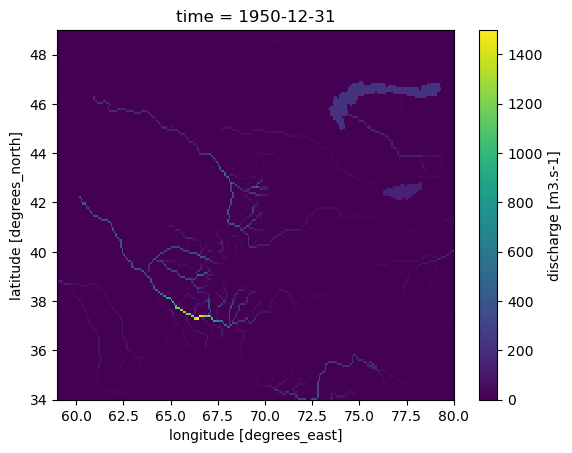

In [5]:
path_to_file_2rivers_c = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_144140/netcdf/discharge_dailyTot_output.nc"
ds_2riv_c = xr.open_dataset(path_to_file_2rivers_c)
ds_2riv_c['discharge'].isel(time=-1).plot()
da_2riv_c=ds_2riv_c['discharge'].isel(time=-150)

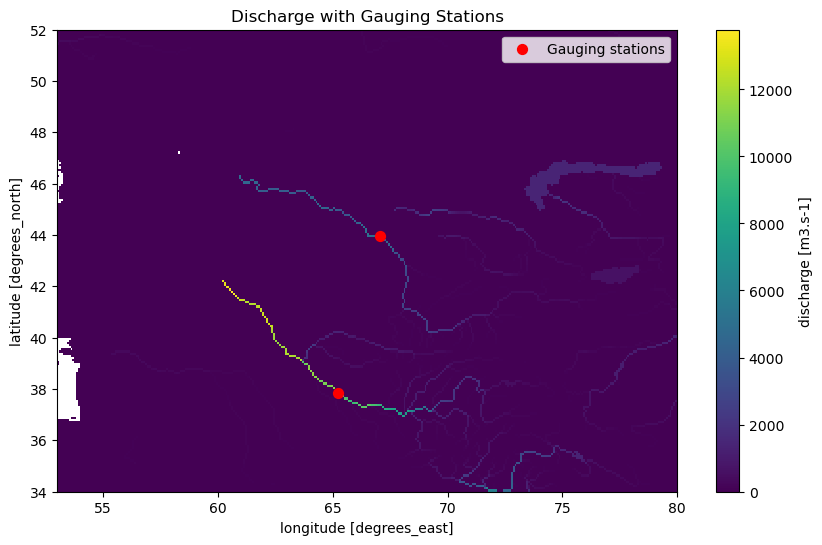

In [6]:
path_to_file_basin = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_091650/netcdf/discharge_dailyTot_output.nc"
ds_basin = xr.open_dataset(path_to_file_basin)

# Suppose discharge has dims [time, y, x] or [time, lat, lon]
da_basin = ds_basin['discharge'].isel(time=-150)  # last timestep

plt.figure(figsize=(10,6))
# Plot the 2D field
im = da_basin.plot(cmap='viridis')  # or whatever colormap you like

# Coordinates of your gauging stations
# Example: lon/lat arrays or lists
station_lon = [Kerki_station_longitude, station_longitude]  # replace with your stations
station_lat = [Kerki_station_latitude, station_latitude]

# Overlay markers
plt.scatter(station_lon, station_lat, color='red', s=50, marker='o', label='Gauging stations')

plt.title("Discharge with Gauging Stations")
plt.legend()
plt.show()

In [7]:
# path_to_file_2riv_2 = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_141338/netcdf/discharge_dailyTot_output.nc"
# ds_2riv_2nd = xr.open_dataset(path_to_file_2riv_2)
# ds_2riv_2nd['discharge'].isel(time=-1).plot()

In [8]:
# path_to_file_2riv_C = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_143602/netcdf/discharge_dailyTot_output.nc"
# ds_2riv_C = xr.open_dataset(path_to_file_2riv_C)
# ds_2riv_C['discharge'].isel(time=-1).plot()

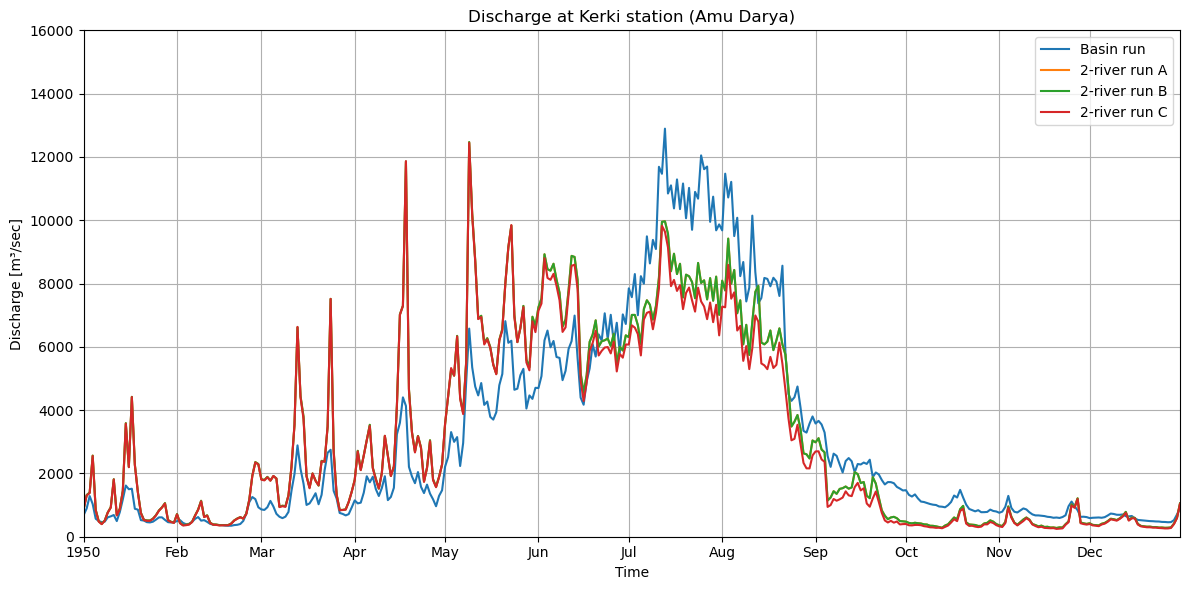

In [9]:
Kerki_station_latitude = 37.8396310038444 #Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334



q_point_basin = ds_basin["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

q_point_2riv = ds_2riv["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

q_point_2riv2nd = ds_2riv_b["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

q_point_2riv3nd = ds_2riv_c["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)


fig, ax = plt.subplots(figsize=(12, 6))

q_point_basin.plot(
    ax=ax,
    label="Basin run",
)

q_point_2riv.plot(
    ax=ax,
    label="2-river run A",
)

q_point_2riv2nd.plot(
    ax=ax,
    label="2-river run B",
)

q_point_2riv3nd.plot(
    ax=ax,
    label="2-river run C",
)



ax.set_xlabel("Time")
ax.set_ylabel("Discharge [m³/sec]")  # adjust if you convert to m³/s
ax.set_title("Discharge at Kerki station (Amu Darya)")

ax.legend()
ax.grid(True)


plt.ylim(0,16000)
plt.xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("1950-12-31"))
plt.tight_layout()
plt.show()

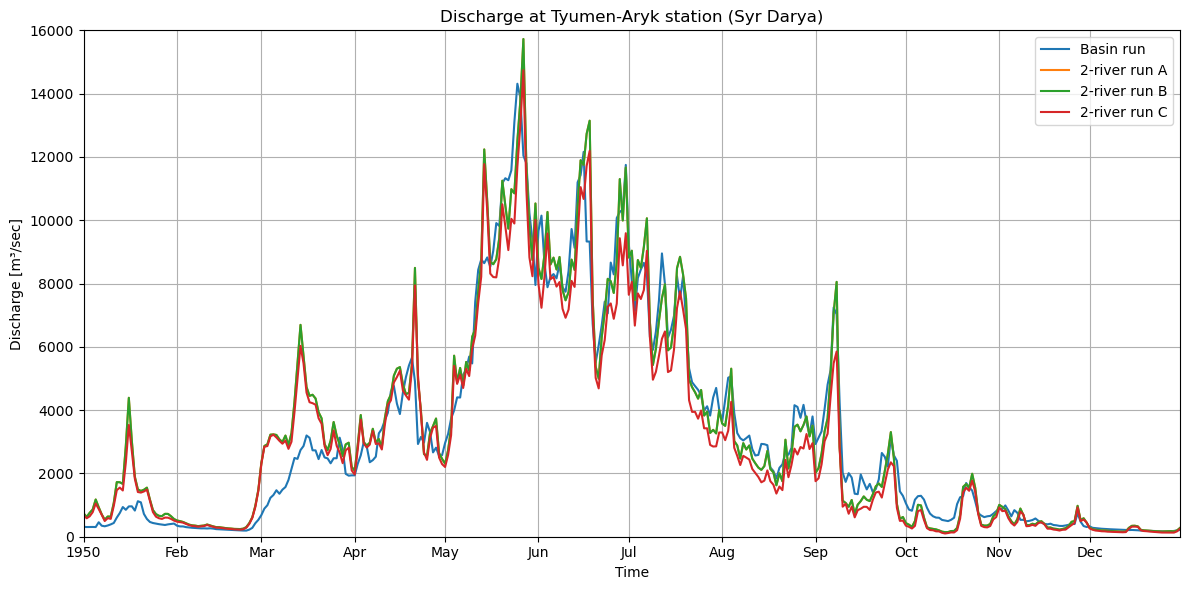

In [10]:
station_latitude = 44.05-0.1 # Syr Darya near Tyumen, through trial and error
station_longitude = 67.05

lat_pt = 45.0
lon_pt = 60.0

q_point_basin = ds_basin["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2riv = ds_2riv["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2riv2nd = ds_2riv_b["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2riv3nd = ds_2riv_c["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)


# q_point_2rivC = ds_2riv_C["discharge"].sel(
#     lat=station_latitude,
#     lon=station_longitude,
#     method="nearest"
# )


fig, ax = plt.subplots(figsize=(12, 6))

q_point_basin.plot(
    ax=ax,
    label="Basin run",
)

q_point_2riv.plot(
    ax=ax,
    label="2-river run A",
)

q_point_2riv2nd.plot(
    ax=ax,
    label="2-river run B",
)

q_point_2riv3nd.plot(
    ax=ax,
    label="2-river run C",
)



ax.set_xlabel("Time")
ax.set_ylabel("Discharge [m³/sec]")  # adjust if you convert to m³/s
ax.set_title("Discharge at Tyumen-Aryk station (Syr Darya)")

ax.legend()
ax.grid(True)


plt.ylim(0,16000)
plt.tight_layout()
plt.xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("1950-12-31"))
plt.show()

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapefile  
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature


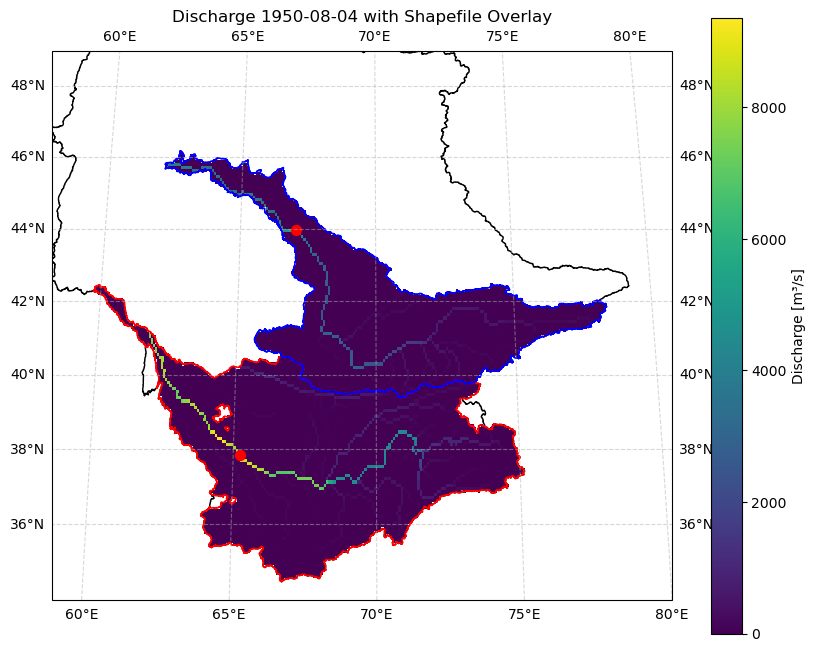

In [12]:
plt.figure(figsize=(10,8))

# Set up map with PlateCarree projection
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax = plt.axes(projection=ccrs.LambertConformal(
#     central_longitude=65,  # roughly central for your basin
#     central_latitude=43,   # roughly central for your basin
#     standard_parallels=(41, 45)  # latitude(s) where scale is true
# ))

ax = plt.axes(projection=ccrs.Mollweide(central_longitude=69.5))


# Plot discharge field
# xarray's .plot works with ax, but set transform=ccrs.PlateCarree()
im = da_2riv_a.plot(ax=ax, cmap='viridis', 
             transform=ccrs.PlateCarree(),  # your data is in lon/lat
             cbar_kwargs={'label': 'Discharge [m³/s]'})

# # Overlay shapefile
shp_path_AD = SHAPEFILES / "Chatly_GRDC/Chatly_GRDC.shp"
shp_path_SD = SHAPEFILES / "Kazalinsk_GRDC/Kazalinsk_GRDC.shp"
shp_path_AB = SHAPEFILES / "AralSea_basin/AralSea_basin.shp"
# Create Cartopy feature from shapefile
shape_feature_AD = ShapelyFeature(Reader(shp_path_AD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='red', linewidth=1, label = "AD")
shape_feature_SD = ShapelyFeature(Reader(shp_path_SD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='blue', linewidth=1, label = "SD")
shape_feature_AB = ShapelyFeature(Reader(shp_path_AB).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='black', linewidth=1, label = "SD")


# Plot
ax.add_feature(shape_feature_AB)
ax.add_feature(shape_feature_AD)
ax.add_feature(shape_feature_SD)

# Coordinates of your gauging stations
# Example: lon/lat arrays or lists
station_lon = [Kerki_station_longitude, station_longitude]  # replace with your stations
station_lat = [Kerki_station_latitude, station_latitude]

# Overlay markers
# Scatter plot of stations
ax.scatter(
    station_lon,
    station_lat,
    color='red',
    s=50,
    marker='o',
    label='Gauging stations',
    transform=ccrs.PlateCarree()  # <--- IMPORTANT: tells Cartopy these coords are lon/lat
)

# lon_min, lon_max = 59, 64   # adjust to your basin
# lat_min, lat_max = 39, 43   # adjust to your basin
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# lon_min, lon_max = 53, 80   # adjust to your basin
# lat_min, lat_max = 34, 52   # adjust to your basin
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

date_only = da_2riv_a.time.values.astype('M8[D]')
# Add coastlines, gridlines
ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha = 0.5)
plt.title(f"Discharge {date_only} with Shapefile Overlay")
plt.show()


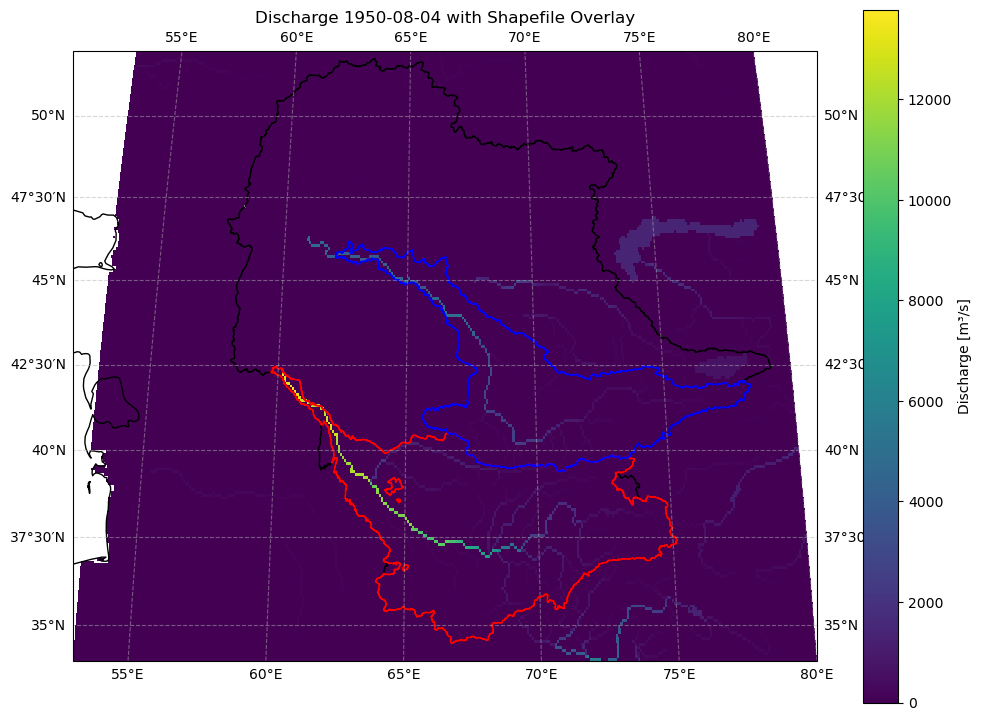

In [13]:
plt.figure(figsize=(12,9))

# Set up map with PlateCarree projection
# ax = plt.axes(projection=ccrs.PlateCarree())
ax = plt.axes(projection=ccrs.Mollweide(central_longitude=66.5))
# ax = plt.axes(projection=ccrs.LambertConformal(
#     central_longitude=65,  # roughly central for your basin
#     central_latitude=43,   # roughly central for your basin
#     standard_parallels=(41, 45)  # latitude(s) where scale is true
# ))


# Plot discharge field
# xarray's .plot works with ax, but set transform=ccrs.PlateCarree()
im = da_basin.plot(ax=ax, cmap='viridis', 
             transform=ccrs.PlateCarree(),  # your data is in lon/lat
             cbar_kwargs={'label': 'Discharge [m³/s]'})

# # Overlay shapefile
shp_path_AD = SHAPEFILES / "Chatly_GRDC/Chatly_GRDC.shp"
shp_path_SD = SHAPEFILES / "Kazalinsk_GRDC/Kazalinsk_GRDC.shp"
shp_path_AB = SHAPEFILES / "AralSea_basin/AralSea_basin.shp"
# Create Cartopy feature from shapefile
shape_feature_AD = ShapelyFeature(Reader(shp_path_AD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='red', linewidth=1, label = "AD")
shape_feature_SD = ShapelyFeature(Reader(shp_path_SD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='blue', linewidth=1, label = "SD")
shape_feature_AB = ShapelyFeature(Reader(shp_path_AB).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='black', linewidth=1, label = "SD")


# Plot
ax.add_feature(shape_feature_AB)
ax.add_feature(shape_feature_AD)
ax.add_feature(shape_feature_SD)


date_only = da_basin.time.values.astype('M8[D]')


# lon_min, lon_max = 59, 64   # adjust to your basin
# lat_min, lat_max = 39, 43   # adjust to your basin

# lon_min, lon_max = 53, 80   # adjust to your basin
# lat_min, lat_max = 34, 52   # adjust to your basin
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())



# Add coastlines, gridlines
ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha = 0.5)
plt.title(f"Discharge {date_only} with Shapefile Overlay")
plt.show()


In [14]:
# "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_105252/netcdf/discharge_dailyTot_output.nc"

In [15]:
# file1="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_105252/pcrglobwb_ewatercycle.ini"
# file2="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/Test_several_runs/pcrglobwb_20260115_091650/pcrglobwb_ewatercycle.ini"

# compare_inis(file1,file2)

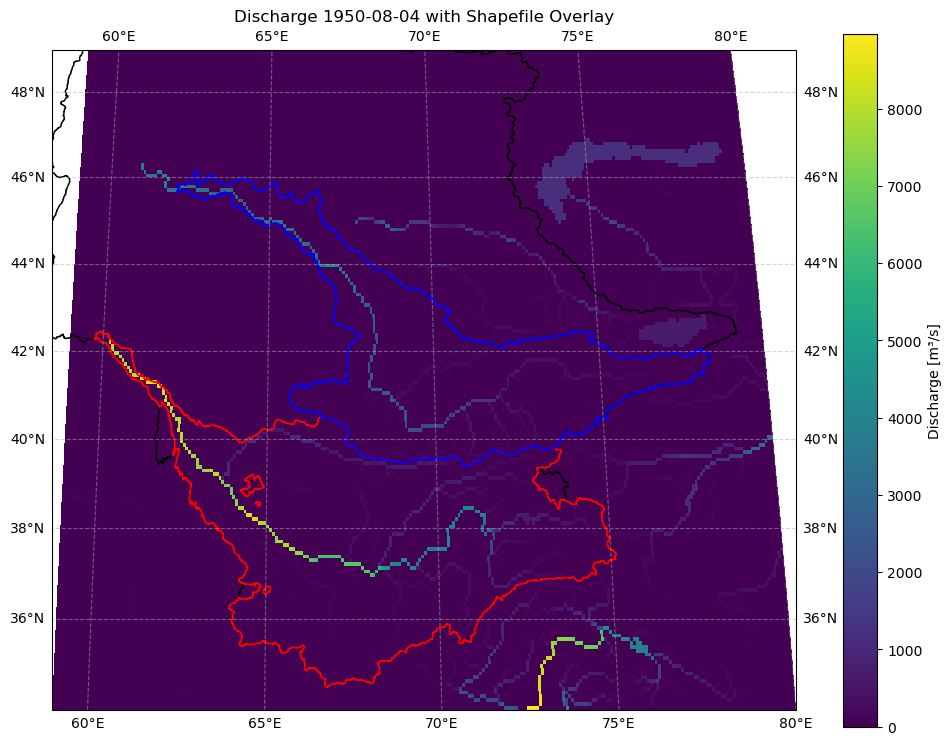

In [16]:
plt.figure(figsize=(12,9))

# Set up map with PlateCarree projection
# ax = plt.axes(projection=ccrs.PlateCarree())
ax = plt.axes(projection=ccrs.Mollweide(central_longitude=66.5))
# ax = plt.axes(projection=ccrs.LambertConformal(
#     central_longitude=65,  # roughly central for your basin
#     central_latitude=43,   # roughly central for your basin
#     standard_parallels=(41, 45)  # latitude(s) where scale is true
# ))


# Plot discharge field
# xarray's .plot works with ax, but set transform=ccrs.PlateCarree()
im = da_2riv_c.plot(ax=ax, cmap='viridis', 
             transform=ccrs.PlateCarree(),  # your data is in lon/lat
             cbar_kwargs={'label': 'Discharge [m³/s]'})

# # Overlay shapefile
shp_path_AD = SHAPEFILES / "Chatly_GRDC/Chatly_GRDC.shp"
shp_path_SD = SHAPEFILES / "Kazalinsk_GRDC/Kazalinsk_GRDC.shp"
shp_path_AB = SHAPEFILES / "AralSea_basin/AralSea_basin.shp"
# Create Cartopy feature from shapefile
shape_feature_AD = ShapelyFeature(Reader(shp_path_AD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='red', linewidth=1, label = "AD")
shape_feature_SD = ShapelyFeature(Reader(shp_path_SD).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='blue', linewidth=1, label = "SD")
shape_feature_AB = ShapelyFeature(Reader(shp_path_AB).geometries(),
                               ccrs.PlateCarree(),
                               facecolor='none', edgecolor='black', linewidth=1, label = "SD")


# Plot
ax.add_feature(shape_feature_AB)
ax.add_feature(shape_feature_AD)
ax.add_feature(shape_feature_SD)


date_only = da_basin.time.values.astype('M8[D]')


# lon_min, lon_max = 59, 64   # adjust to your basin
# lat_min, lat_max = 39, 43   # adjust to your basin

# lon_min, lon_max = 53, 80   # adjust to your basin
# lat_min, lat_max = 34, 52   # adjust to your basin
# ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())



# Add coastlines, gridlines
ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha = 0.5)
plt.title(f"Discharge {date_only} with Shapefile Overlay")
plt.show()
